In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("../data/processed/cicids2017_clean.csv")
df.columns = df.columns.str.strip()
df["is_attack"] = (df["Label"] != "BENIGN").astype(int)

# Örnekleme: tam veri üzerinde RF eğitimi yavaş olacağı için
df_sample = df.sample(n=min(100_000, len(df)), random_state=42)

X = df_sample.drop(["Label", "is_attack"], axis=1)
y = df_sample["is_attack"]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(80000, 78) (20000, 78) (80000,) (20000,)


In [4]:
rf_model = RandomForestClassifier(
    n_estimators=200,        #daha stabil importance
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
rf_model.fit(X, y)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [5]:
feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)
feature_importances

Flow Duration                  0.080190
Fwd Packet Length Mean         0.068300
Subflow Fwd Bytes              0.066811
Total Length of Fwd Packets    0.062821
Fwd Packet Length Std          0.051866
                                 ...   
Bwd PSH Flags                  0.000000
Fwd Avg Packets/Bulk           0.000000
Fwd Avg Bytes/Bulk             0.000000
CWE Flag Count                 0.000000
Bwd Avg Bulk Rate              0.000000
Length: 78, dtype: float64

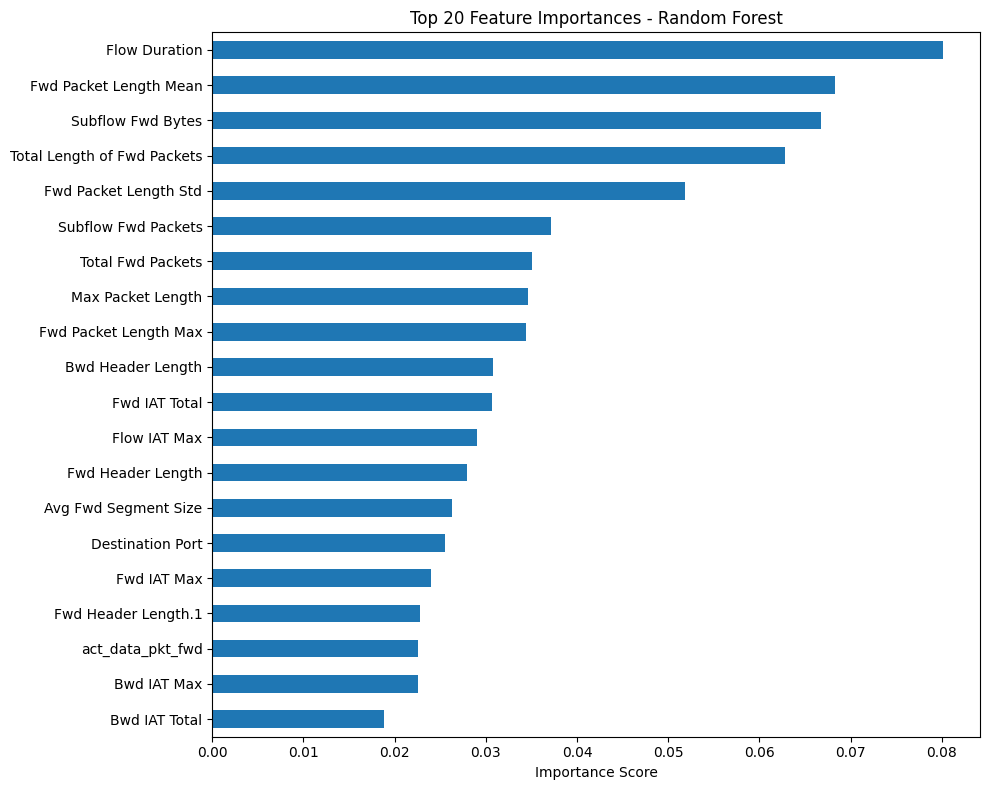

In [6]:
top20 = feature_importances.head(20)

plt.figure(figsize=(10,8))
top20.sort_values().plot(kind="barh")
plt.title("Top 20 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()




In [7]:
from sklearn.metrics import classification_report

top10 = feature_importances.head(10).index

X_train_top10 = X_train[top10]
X_test_top10  = X_test[top10]

rf_top10 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_top10.fit(X_train_top10, y_train)
y_pred_top10 = rf_top10.predict(X_test_top10)

print(classification_report(y_test, y_pred_top10))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19997
           1       1.00      0.33      0.50         3

    accuracy                           1.00     20000
   macro avg       1.00      0.67      0.75     20000
weighted avg       1.00      1.00      1.00     20000



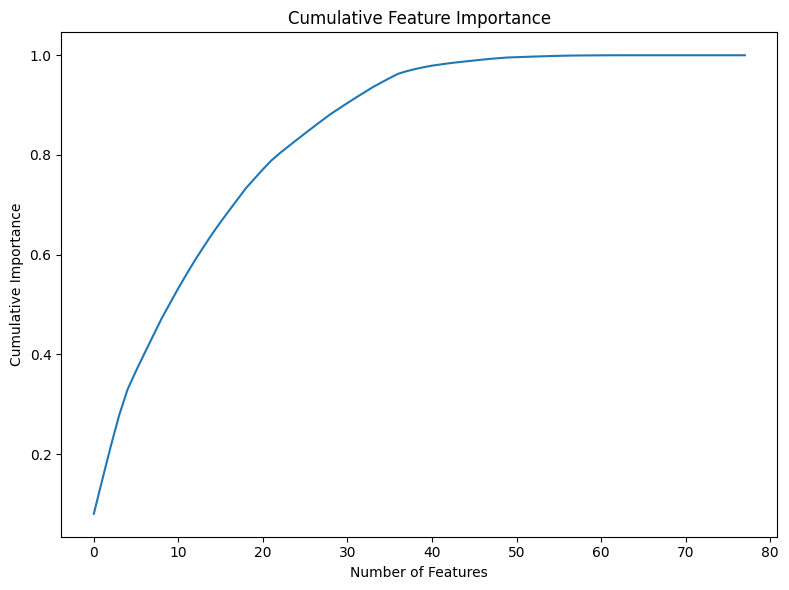

In [8]:
cumulative_importance = feature_importances.cumsum()

plt.figure(figsize=(8,6))
plt.plot(cumulative_importance.values)
plt.title("Cumulative Feature Importance")
plt.xlabel("Number of Features")
plt.ylabel("Cumulative Importance")
plt.tight_layout()
plt.show()



In [9]:
cumulative_importance.head(20)

Flow Duration                  0.080190
Fwd Packet Length Mean         0.148490
Subflow Fwd Bytes              0.215301
Total Length of Fwd Packets    0.278122
Fwd Packet Length Std          0.329988
Subflow Fwd Packets            0.367185
Total Fwd Packets              0.402272
Max Packet Length              0.436892
Fwd Packet Length Max          0.471351
Bwd Header Length              0.502152
Fwd IAT Total                  0.532876
Flow IAT Max                   0.561882
Fwd Header Length              0.589813
Avg Fwd Segment Size           0.616159
Destination Port               0.641663
Fwd IAT Max                    0.665670
Fwd Header Length.1            0.688409
act_data_pkt_fwd               0.711029
Bwd IAT Max                    0.733599
Bwd IAT Total                  0.752437
dtype: float64

In [10]:
top10 = feature_importances.head(10).index

X_train_top10 = X_train[top10]
X_test_top10 = X_test[top10]

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_top10 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_top10.fit(X_train_top10, y_train)
y_pred_top10 = rf_top10.predict(X_test_top10)

print(classification_report(y_test, y_pred_top10))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19997
           1       1.00      0.33      0.50         3

    accuracy                           1.00     20000
   macro avg       1.00      0.67      0.75     20000
weighted avg       1.00      1.00      1.00     20000



##### top5,top15,%90 cumulative karşılaştırma

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
import pandas as pd

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42,stratify=y
)

rf_full= RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight = "balanced",
    n_jobs=1
)

rf_full.fit(X_train,y_train)
y_pred_full = rf_full.predict(X_test)

print("Full Model Report")
print(classification_report(y_test,y_pred_full))

Full Model Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19997
           1       1.00      1.00      1.00         3

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



In [13]:
feature_importances = pd.Series(
    rf_full.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importances.head(20)

Flow Duration                  0.095331
Fwd Packet Length Mean         0.062634
Total Length of Fwd Packets    0.058915
Total Fwd Packets              0.051756
Subflow Fwd Bytes              0.047449
Bwd IAT Total                  0.038652
act_data_pkt_fwd               0.036028
Max Packet Length              0.033481
Fwd Packet Length Max          0.032445
Fwd Header Length              0.031442
Fwd Header Length.1            0.030034
Subflow Fwd Packets            0.029856
Fwd Packet Length Std          0.029006
Fwd IAT Max                    0.026211
Flow IAT Max                   0.025893
Fwd IAT Total                  0.024941
Bwd IAT Max                    0.024895
Destination Port               0.024455
Avg Fwd Segment Size           0.021667
Bwd Packet Length Mean         0.020475
dtype: float64

In [14]:
from sklearn.metrics import precision_score, recall_score

def train_eval_topk(k: int):
    feats = feature_importances.head(k).index
    Xtr = X_train[feats]
    Xte = X_test[feats]

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)

    return {
        "k_features": k,
        "precision_attack": precision_score(y_test, pred, pos_label=1),
        "recall_attack": recall_score(y_test, pred, pos_label=1),
        "f1_attack": f1_score(y_test, pred, pos_label=1),
    }

results = pd.DataFrame([train_eval_topk(k) for k in [5,10,15,20,30]])
results

,k_features,precision_attack,recall_attack,f1_attack
0,5,1.0,0.333333,0.5
1,10,1.0,0.333333,0.5
2,15,1.0,0.333333,0.5
3,20,1.0,0.666667,0.8
4,30,1.0,1.000000,1.0


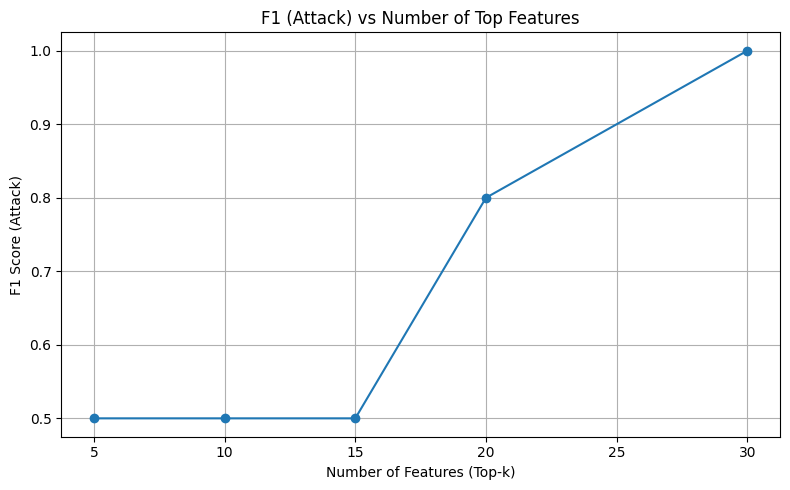

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(results["k_features"], results["f1_attack"], marker="o")
plt.title("F1 (Attack) vs Number of Top Features")
plt.xlabel("Number of Features (Top-k)")
plt.ylabel("F1 Score (Attack)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
cumulative = feature_importances.cumsum()
k90 = (cumulative <= 0.90).sum() + 1
k95 = (cumulative <= 0.95).sum() + 1

k90, k95

(np.int64(31), np.int64(37))

In [17]:
results_threshold = pd.DataFrame([train_eval_topk(k90), train_eval_topk(k95)])
results_threshold

,k_features,precision_attack,recall_attack,f1_attack
0,31,1.0,1.0,1.0
1,37,1.0,1.0,1.0


In [18]:
from sklearn.model_selection import cross_val_score

rf_cv = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

scores = cross_val_score(
    rf_cv,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("CV F1 scores:", scores)
print("Mean CV F1:", scores.mean())

CV F1 scores: [0.66666667 0.         0.         0.66666667 1.        ]
Mean CV F1: 0.4666666666666666


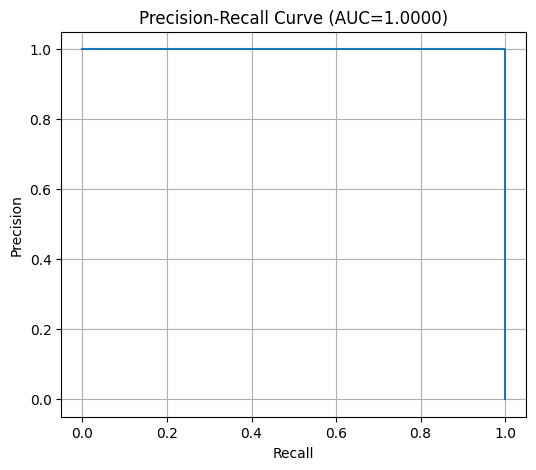

PR-AUC: 1.0


In [19]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# probability tahmini
y_scores = rf_full.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AUC={pr_auc:.4f})")
plt.grid(True)
plt.show()

print("PR-AUC:", pr_auc)

In [20]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.linspace(0.0, 1.0, 200)

f1_scores = []

for t in thresholds:
    y_pred_thresh = (y_scores >= t).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    f1_scores.append(f1)

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)

Best Threshold: 0.19095477386934673
Best F1: 1.0


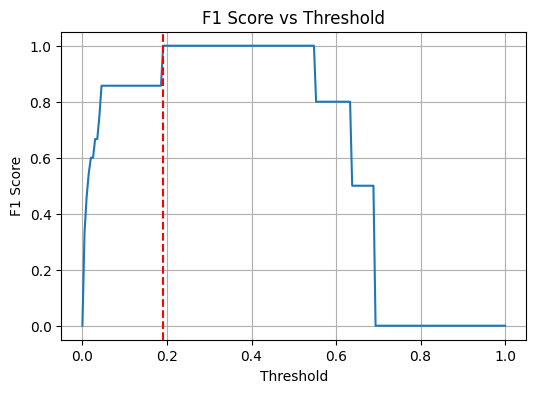

In [21]:
plt.figure(figsize=(6,4))
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, color="red", linestyle="--")
plt.title("F1 Score vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.grid(True)
plt.show()

In [22]:
def get_top_features(seed):
    model = RandomForestClassifier(
        n_estimators=200,
        random_state=seed,
        class_weight="balanced",
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    fi = pd.Series(model.feature_importances_, index=X_train.columns)
    return fi.sort_values(ascending=False).head(10).index.tolist()

top_seed_42 = get_top_features(42)
top_seed_7  = get_top_features(7)
top_seed_99 = get_top_features(99)

print("Seed 42:", top_seed_42)
print("Seed 7 :", top_seed_7)
print("Seed 99:", top_seed_99)

Seed 42: ['Flow Duration', 'Fwd Packet Length Mean', 'Total Length of Fwd Packets', 'Total Fwd Packets', 'Subflow Fwd Bytes', 'Bwd IAT Total', 'act_data_pkt_fwd', 'Max Packet Length', 'Fwd Packet Length Max', 'Fwd Header Length']
Seed 7 : ['Subflow Fwd Bytes', 'Fwd Packet Length Mean', 'Avg Fwd Segment Size', 'Fwd Packet Length Std', 'act_data_pkt_fwd', 'Flow Duration', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Bwd IAT Total', 'Flow IAT Max']
Seed 99: ['Total Length of Fwd Packets', 'act_data_pkt_fwd', 'Subflow Fwd Bytes', 'Avg Fwd Segment Size', 'Flow Duration', 'Subflow Fwd Packets', 'Fwd Packet Length Max', 'Bwd IAT Total', 'Fwd Packet Length Mean', 'Max Packet Length']
